In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## 1) Flirt Dataset
a. Classification Problem Statement Flirt or Neutral

In [4]:
df = pd.read_csv("flirt_dataset_1000.csv", on_bad_lines = 'skip', encoding = 'utf8')
df

,Name,Chat,Label
0,Vikram,Missed call from Vikram 📞,Neutral
1,Neha,I wish you were here 😍,Flirt
2,Meena,Missed call from Meena 📞,Neutral
3,Asha,"Okay, noted 👍",Neutral
4,Vikram,You make me smile 😊,Flirt
...,...,...,...
995,Vikram,I wish you were here 😍,Flirt
996,Meena,You're special to me 💕,Flirt
997,Vikram,Saw your missed call,Neutral
998,Neha,I had dinner,Neutral


In [5]:
len(df)

1000

In [6]:
df = df.drop_duplicates(subset=['Chat'], keep='first')
df = df.reset_index(drop=True)

In [7]:
len(df)

28

In [8]:
dataset = df
y = dataset['Label']

In [9]:
dataset.describe()

,Name,Chat,Label
count,28,28,28
unique,8,28,2
top,Rahul,Missed call from Vikram 📞,Neutral
freq,7,1,20


In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    28 non-null     object
 1   Chat    28 non-null     object
 2   Label   28 non-null     object
dtypes: object(3)
memory usage: 804.0+ bytes


In [11]:
x_train, x_test, y_train, y_test = train_test_split(dataset['Chat'], y, test_size = 0.33, random_state = 42)

In [12]:
x_train

15      Hey, what are you doing?
1         I wish you were here 😍
4            You make me smile 😊
5                   I had dinner
2       Missed call from Meena 📞
16     Did you finish your work?
23           Let’s meet tomorrow
3                  Okay, noted 👍
26      Missed call from Arjun 📞
24        I will reach home soon
18    What’s the plan for today?
27      Missed call from Priya 📞
20        Call me back when free
7        You looked nice today 😍
10         I tried calling you 📞
14                    Miss me? 😜
19      I like talking to you ❤️
6     I was thinking about you 😊
Name: Chat, dtype: object

#### b. Combination of model with Counter vector + MultinomialNB

In [13]:
count_vectorizer = CountVectorizer(stop_words = 'english')
count_train = count_vectorizer.fit_transform(x_train)
print(count_train)
count_test = count_vectorizer.transform(x_test)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 35 stored elements and shape (18, 32)>
  Coords	Values
  (0, 7)	1
  (0, 4)	1
  (1, 30)	1
  (2, 12)	1
  (2, 23)	1
  (3, 3)	1
  (4, 16)	1
  (4, 13)	1
  (5, 2)	1
  (5, 5)	1
  (5, 31)	1
  (6, 9)	1
  (6, 14)	1
  (6, 28)	1
  (7, 19)	1
  (7, 18)	1
  (8, 16)	1
  (8, 0)	1
  (9, 22)	1
  (9, 8)	1
  (9, 24)	1
  (10, 20)	1
  (10, 27)	1
  (11, 16)	1
  (11, 21)	1
  (12, 6)	1
  (13, 27)	1
  (13, 11)	1
  (13, 17)	1
  (14, 29)	1
  (14, 1)	1
  (15, 15)	1
  (16, 10)	1
  (16, 25)	1
  (17, 26)	1


In [14]:
len(count_vectorizer.get_feature_names_out())

32

In [15]:
count_vectorizer.get_feature_names_out()

array(['arjun', 'calling', 'did', 'dinner', 'doing', 'finish', 'free',
       'hey', 'home', 'let', 'like', 'looked', 'make', 'meena', 'meet',
       'miss', 'missed', 'nice', 'noted', 'okay', 'plan', 'priya',
       'reach', 'smile', 'soon', 'talking', 'thinking', 'today',
       'tomorrow', 'tried', 'wish', 'work'], dtype=object)

In [16]:
print(count_train.toarray())

[[0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 

## Multinomial Naive Bayes

In [17]:
clf = MultinomialNB()
clf.fit(count_train, y_train)
pred = clf.predict(count_test)
score = metrics.accuracy_score(y_test, pred)
print("Accuracy: %0.3f" %score)

cm = metrics.confusion_matrix(y_test, pred, labels = ['Flirt','Neutral'])
report = classification_report(y_test, pred)
print(report)

Accuracy: 0.800
              precision    recall  f1-score   support

       Flirt       0.00      0.00      0.00         2
     Neutral       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10



C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
#count_train[1]
count_vectorizer = CountVectorizer(stop_words = 'english')
count_train = count_vectorizer.fit_transform(x_train)
clf.predict(count_train[[13]])

array(['Flirt'], dtype='<U7')

#### b. Combination of model with TFIDF vector + MultinomialNB

In [19]:
# TFIDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

tfidf_train = tfidf_vectorizer.fit_transform(x_train)
tfidf_test = tfidf_vectorizer.transform(x_test)

#print(tfidf_train)

# Model
clf = MultinomialNB()
clf.fit(tfidf_train, y_train)
pred = clf.predict(tfidf_test)
score = metrics.accuracy_score(y_test, pred)
print("Accuracy: %0.3f" %score)

cm = metrics.confusion_matrix(y_test, pred, labels = ['Flirt','Neutral'])
#print(cm)

from sklearn.metrics import classification_report
report = classification_report(y_test, pred)
print(report)

Accuracy: 0.800
              precision    recall  f1-score   support

       Flirt       0.00      0.00      0.00         2
     Neutral       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10



C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### b. Combination of model with Hashing vector + MultinomialNB

In [20]:
# Hash Vectorizer
hash_vectorizer = HashingVectorizer(n_features=10, stop_words="english",
       alternate_sign=False )
hash_train = hash_vectorizer.fit_transform(x_train)
hash_test = hash_vectorizer.transform(x_test)
#print(hash_train)
# Model
clf = MultinomialNB()
clf.fit(hash_train, y_train)
pred = clf.predict(hash_test)
score = metrics.accuracy_score(y_test, pred)
print("Accuracy: %0.3f" %score)

cm = metrics.confusion_matrix(y_test, pred, labels = ['Flirt','Neutral'])
#print(cm)

from sklearn.metrics import classification_report
report = classification_report(y_test, pred)
print(report)

Accuracy: 0.800
              precision    recall  f1-score   support

       Flirt       0.00      0.00      0.00         2
     Neutral       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10



C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\snaptube\AnacondaPython\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Passive Aggressive Classifier

#### b. Combination of model with Counter vector + PAC

In [21]:
from sklearn.linear_model import PassiveAggressiveClassifier
clf = PassiveAggressiveClassifier(max_iter=1000, random_state=0, tol=1e-3)
clf.fit(count_train, y_train)
pred = clf.predict(count_test)
score = metrics.accuracy_score(y_test, pred)
print("Accuracy: %0.3f" %score)

cm = metrics.confusion_matrix(y_test, pred, labels = ['Flirt','Neutral'])

Accuracy: 0.800


#### b. Combination of model with TFIDF vector + PAC

In [22]:
# TFIDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

tfidf_train = tfidf_vectorizer.fit_transform(x_train)
tfidf_test = tfidf_vectorizer.transform(x_test)

#print(tfidf_train)

# Model
clf = PassiveAggressiveClassifier(max_iter=1000,random_state=0, tol=1e-3)
clf.fit(tfidf_train, y_train)

# Prediction
pred = clf.predict(tfidf_test)

# Accuracy
score = metrics.accuracy_score(y_test, pred)
print("Accuracy: %0.3f" % score)

# Confusion Matrix
cm = metrics.confusion_matrix(y_test, pred, labels=['Flirt','Neutral'])
print(cm)

Accuracy: 0.800
[[0 2]
 [0 8]]


## c. Final Model
Combination of model with Hashing vector + PAC

In [23]:
# Hash_vectorizer
hash_vectorizer = HashingVectorizer()
hash_train = hash_vectorizer.fit_transform(x_train)
hash_test = hash_vectorizer.transform(x_test)
#print(hash_train)
clf = PassiveAggressiveClassifier(max_iter=1000,random_state=0, tol=1e-3)
clf.fit(hash_train, y_train)
pred = clf.predict(hash_test)

score = metrics.accuracy_score(pred, y_test)
print("Accuracy: %0.3f" % score)

cm = metrics.confusion_matrix(y_test, pred, labels=['Flirt','Neutral'])
print(cm)

Accuracy: 0.900
[[1 1]
 [0 8]]


## 2) Flirt Model checked with each row

In [24]:
dataset["Chat"][20]

'Call me back when free'

In [25]:
count_train[[0]]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2 stored elements and shape (1, 32)>

In [26]:
#count_train[1]
hash_vectorizer = HashingVectorizer()
hash_train = hash_vectorizer.fit_transform(x_train)

In [27]:
clf.predict(hash_train[[9]])

array(['Neutral'], dtype='<U7')

## 3) Talkative, Less talkative

In [28]:
df['Name'].value_counts()

Name
Rahul     7
Asha      5
Meena     4
Arjun     4
Vikram    2
Neha      2
Priya     2
Kiran     2
Name: count, dtype: int64

#### Talkative is Rahul; Less talkative is Vikram, Neha, Priya, Kiran

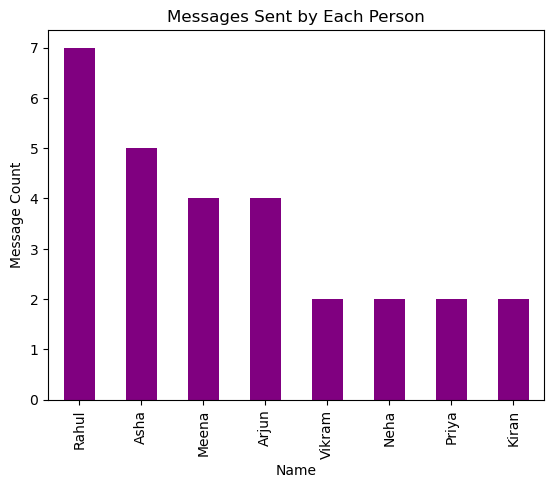

In [38]:
count = df['Name'].value_counts()
plt.figure()
count.plot(kind = 'bar',color = 'purple')
plt.xlabel("Name")
plt.ylabel("Message Count")
plt.title("Messages Sent by Each Person")
plt.show()

## 6) Missed call all

Name
Vikram    1
Meena     1
Kiran     1
Rahul     1
Neha      1
Asha      1
Arjun     1
Priya     1
Name: count, dtype: int64
      Name                       Chat    Label
0   Vikram  Missed call from Vikram 📞  Neutral
2    Meena   Missed call from Meena 📞  Neutral
11   Kiran   Missed call from Kiran 📞  Neutral
17   Rahul   Missed call from Rahul 📞  Neutral
21    Neha    Missed call from Neha 📞  Neutral
25    Asha    Missed call from Asha 📞  Neutral
26   Arjun   Missed call from Arjun 📞  Neutral
27   Priya   Missed call from Priya 📞  Neutral


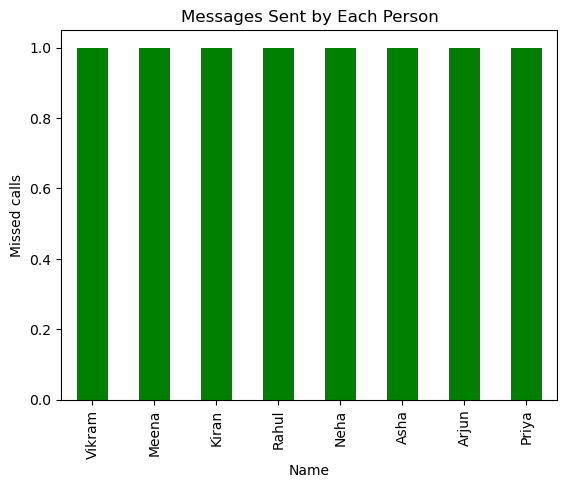

In [44]:
missed_calls = df[df['Chat'].str.contains("Missed call", case=True)]
cmc = missed_calls['Name'].value_counts()
print(cmc)
print(missed_calls)
plt.figure()
cmc.plot(kind = 'bar',color = 'green')
plt.xlabel("Name")
plt.ylabel("Missed calls")
plt.title("Messages Sent by Each Person")
plt.show()